ID seeds : [42, 43, 44, 45, 46]
OOD seeds: [42, 43, 44, 45, 46]

ID — single_head_frozen
 year             method   mean    std  n ci_low ci_high
 2002 single_head_frozen 0.2850 0.0063  5 0.2772  0.2928
 2003 single_head_frozen 0.3772 0.0114  5 0.3631  0.3913
 2004 single_head_frozen 0.3633 0.0094  5 0.3516  0.3750
 2005 single_head_frozen 0.3701 0.0155  5 0.3508  0.3894
 2006 single_head_frozen 0.4331 0.0093  5 0.4216  0.4446
 2007 single_head_frozen 0.4163 0.0224  5 0.3884  0.4441
 2008 single_head_frozen 0.4322 0.0225  5 0.4042  0.4601
 2009 single_head_frozen 0.4161 0.0104  5 0.4032  0.4290
 2010 single_head_frozen 0.4943 0.0039  5 0.4895  0.4992
 2011 single_head_frozen 0.5505 0.0083  5 0.5402  0.5609
 2012 single_head_frozen 0.5145 0.0063  5 0.5067  0.5224

OOD — single_head_supervised_reference
 year                           method   mean    std  n ci_low ci_high
 2013 single_head_supervised_reference 0.5599 0.0086  5 0.5492  0.5705
 2014 single_head_supervised_reference 0.5884

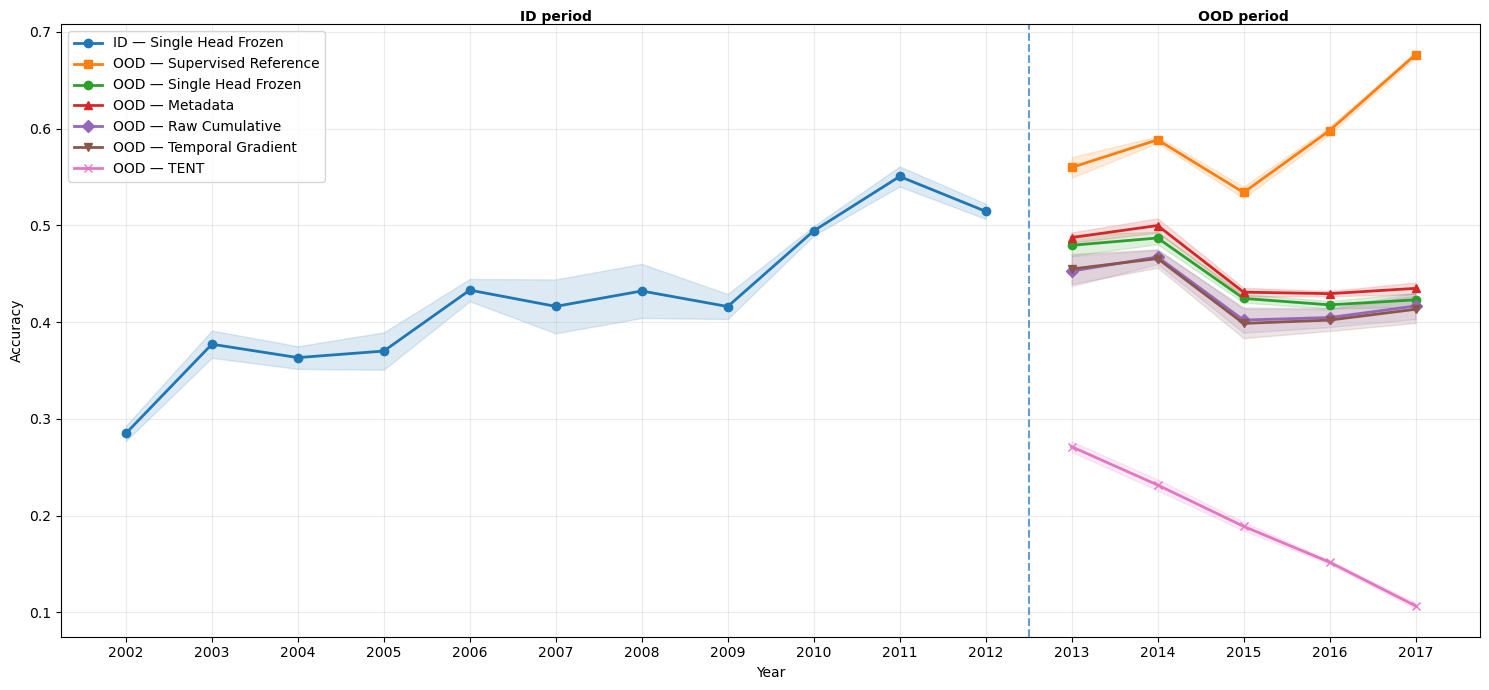

In [5]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t


# ============================================================
# CONFIG
# ============================================================

# Cartella contenente:
# id_42.csv, ..., id_46.csv
# ood_42.csv, ..., ood_46.csv
RESULTS_DIR = Path("results/fmow/eval_stream_tas")

EXPECTED_SEEDS = {42, 43, 44, 45, 46}

CI_LEVEL = 0.95


# ============================================================
# LOAD FILES
# ============================================================

def extract_seed(path: Path) -> int:
    """
    Estrae il numero/seed dal nome del file.
    Es:
        id_42.csv  -> 42
        ood_46.csv -> 46
    """
    match = re.search(r"_(\d+)\.csv$", path.name)

    if match is None:
        raise ValueError(f"Impossibile estrarre il seed da: {path.name}")

    return int(match.group(1))


def load_seed_files(pattern: str) -> pd.DataFrame:
    files = sorted(RESULTS_DIR.glob(pattern))

    if not files:
        raise FileNotFoundError(
            f"Nessun file trovato con pattern '{pattern}' in {RESULTS_DIR.resolve()}"
        )

    dfs = []

    for path in files:
        seed = extract_seed(path)

        df = pd.read_csv(path)

        required_columns = {"year", "method", "accuracy"}

        missing = required_columns - set(df.columns)

        if missing:
            raise ValueError(
                f"{path.name}: mancano le colonne {missing}. "
                f"Colonne presenti: {list(df.columns)}"
            )

        df = df[["year", "method", "accuracy"]].copy()

        df["seed"] = seed
        df["year"] = pd.to_numeric(df["year"])
        df["accuracy"] = pd.to_numeric(df["accuracy"])

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


id_df = load_seed_files("id_*.csv")
ood_df = load_seed_files("ood_*.csv")


# ============================================================
# CHECK SEEDS
# ============================================================

id_seeds = set(id_df["seed"].unique())
ood_seeds = set(ood_df["seed"].unique())

print("ID seeds :", sorted(id_seeds))
print("OOD seeds:", sorted(ood_seeds))

if id_seeds != EXPECTED_SEEDS:
    print(
        f"WARNING: seed ID trovati {sorted(id_seeds)}, "
        f"attesi {sorted(EXPECTED_SEEDS)}"
    )

if ood_seeds != EXPECTED_SEEDS:
    print(
        f"WARNING: seed OOD trovati {sorted(ood_seeds)}, "
        f"attesi {sorted(EXPECTED_SEEDS)}"
    )


# ============================================================
# STATISTICS
# ============================================================

def compute_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcola per ogni year/method:
      - mean
      - sample std
      - numero seed
      - standard error
      - intervallo di confidenza al 95% usando Student-t
    """

    stats = (
        df.groupby(["year", "method"])["accuracy"]
        .agg(
            mean="mean",
            std="std",
            n="count"
        )
        .reset_index()
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["n"])

    alpha = 1 - CI_LEVEL

    stats["t_critical"] = stats["n"].apply(
        lambda n: t.ppf(1 - alpha / 2, df=n - 1)
        if n > 1
        else np.nan
    )

    stats["ci_half"] = stats["t_critical"] * stats["sem"]

    stats["ci_low"] = stats["mean"] - stats["ci_half"]
    stats["ci_high"] = stats["mean"] + stats["ci_half"]

    return stats


id_stats = compute_stats(id_df)
ood_stats = compute_stats(ood_df)


# ============================================================
# SELECT METHODS
# ============================================================

# ID
id_frozen = id_stats[
    id_stats["method"] == "single_head_frozen"
].copy()

id_supervised = id_stats[
    id_stats["method"] == "single_head_supervised_reference"
].copy()


# OOD
ood_methods = [
    "single_head_frozen",
    "metadata",
    "raw_cumulative",
    "temporal_gradient",
    "tent",
]

ood_selected = ood_stats[
    ood_stats["method"].isin(ood_methods)
].copy()


# ============================================================
# PRINT RESULTS
# ============================================================

def print_method_stats(title, df):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

    if df.empty:
        print("Nessun risultato trovato.")
        return

    display_df = df[
        [
            "year",
            "method",
            "mean",
            "std",
            "n",
            "ci_low",
            "ci_high",
        ]
    ].copy()

    print(
        display_df.to_string(
            index=False,
            formatters={
                "mean": "{:.4f}".format,
                "std": "{:.4f}".format,
                "ci_low": "{:.4f}".format,
                "ci_high": "{:.4f}".format,
            }
        )
    )


print_method_stats(
    "ID — single_head_frozen",
    id_frozen
)

print_method_stats(
    "OOD — single_head_supervised_reference",
    id_supervised
)

for method in ood_methods:

    print_method_stats(
        f"OOD — {method}",
        ood_selected[ood_selected["method"] == method]
    )


# ============================================================
# GLOBAL SUMMARY ACROSS YEARS AND SEEDS
# ============================================================

def global_stats(df, method, year_start, year_end):
    """
    Calcola media e deviazione standard usando TUTTE le osservazioni:
    anni × seed.

    Esempio:
    2013-2017 con 5 seed = 25 valori.
    """

    subset = df[
        (df["method"] == method)
        & (df["year"] >= year_start)
        & (df["year"] <= year_end)
    ].copy()

    values = subset["accuracy"].dropna()

    n = len(values)
    mean = values.mean()
    std = values.std(ddof=1)
    sem = std / np.sqrt(n)

    t_critical = t.ppf(
        1 - (1 - CI_LEVEL) / 2,
        df=n - 1
    )

    ci_half = t_critical * sem

    return {
        "method": method,
        "years": f"{year_start}-{year_end}",
        "mean": mean,
        "std": std,
        "n": n,
        "ci_low": mean - ci_half,
        "ci_high": mean + ci_half,
    }


global_results = []

# ID frozen: 2002-2012
global_results.append(
    global_stats(
        id_df,
        "single_head_frozen",
        2002,
        2012
    )
)

# ID supervised reference: 2013-2017
global_results.append(
    global_stats(
        id_df,
        "single_head_supervised_reference",
        2013,
        2017
    )
)

# OOD: 2013-2017
for method in [
    "single_head_frozen",
    "metadata",
    "raw_cumulative",
    "temporal_gradient",
    "tent",
]:
    global_results.append(
        global_stats(
            ood_df,
            method,
            2013,
            2017
        )
    )


global_summary = pd.DataFrame(global_results)


print("\n" + "=" * 100)
print("GLOBAL SUMMARY ACROSS YEARS AND SEEDS")
print("=" * 100)

print(
    global_summary.to_string(
        index=False,
        formatters={
            "mean": "{:.4f}".format,
            "std": "{:.4f}".format,
            "ci_low": "{:.4f}".format,
            "ci_high": "{:.4f}".format,
        }
    )
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(15, 7))


def plot_with_ci(
    ax,
    df,
    label,
    marker="o",
    linewidth=2,
    linestyle="-"
):
    if df.empty:
        return

    df = df.sort_values("year")

    x = df["year"].to_numpy()
    y = df["mean"].to_numpy()

    ci_low = df["ci_low"].to_numpy()
    ci_high = df["ci_high"].to_numpy()

    line, = ax.plot(
        x,
        y,
        marker=marker,
        linewidth=linewidth,
        linestyle=linestyle,
        label=label,
    )

    ax.fill_between(
        x,
        ci_low,
        ci_high,
        alpha=0.15,
        color=line.get_color(),
    )


# ------------------------------------------------------------
# LEFT SIDE: 2002–2012
# ID single head frozen
# ------------------------------------------------------------

left_id = id_frozen[
    (id_frozen["year"] >= 2002)
    & (id_frozen["year"] <= 2012)
]

plot_with_ci(
    ax,
    left_id,
    label="ID — Single Head Frozen",
    marker="o",
)


# ------------------------------------------------------------
# RIGHT SIDE: 2013–2017
# ------------------------------------------------------------

# Supervised reference ID
right_supervised = id_supervised[
    (id_supervised["year"] >= 2013)
    & (id_supervised["year"] <= 2017)
]

plot_with_ci(
    ax,
    right_supervised,
    label="OOD — Supervised Reference",
    marker="s",
)


# OOD methods
right_ood = ood_selected[
    (ood_selected["year"] >= 2013)
    & (ood_selected["year"] <= 2017)
]

plot_specs = {
    "single_head_frozen": {
        "label": "OOD — Single Head Frozen",
        "marker": "o",
    },
    "metadata": {
        "label": "OOD — Metadata",
        "marker": "^",
    },
    "raw_cumulative": {
        "label": "OOD — Raw Cumulative",
        "marker": "D",
    },
    "temporal_gradient": {
        "label": "OOD — Temporal Gradient",
        "marker": "v",
    },
    "tent": {
        "label": "OOD — TENT",
        "marker": "x",
    },
}


for method, spec in plot_specs.items():

    method_df = right_ood[
        right_ood["method"] == method
    ]

    plot_with_ci(
        ax,
        method_df,
        label=spec["label"],
        marker=spec["marker"],
    )


# ============================================================
# VISUAL SEPARATION ID / OOD PERIOD
# ============================================================

ax.axvline(
    x=2012.5,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
)

# Optional labels for the two temporal regions
ymin, ymax = ax.get_ylim()

ax.text(
    2007,
    ymax,
    "ID period",
    ha="center",
    va="bottom",
    fontweight="bold",
)

ax.text(
    2015,
    ymax,
    "OOD period",
    ha="center",
    va="bottom",
    fontweight="bold",
)


# ============================================================
# STYLE
# ============================================================

ax.set_xlabel("Year")
ax.set_ylabel("Accuracy")

ax.set_xticks(range(2002, 2018))

ax.grid(
    True,
    alpha=0.25,
)

ax.legend(
    loc="best",
    frameon=True,
)

plt.tight_layout()
plt.show()